In [75]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [76]:
df = pd.read_csv('customer_segmentation_data.csv')

In [77]:
# Check for null values in each column
print("Null values in each column:")
print(df.isnull().sum())

# Identify and display rows containing nulls
null_rows = df[df.isnull().any(axis=1)]
if not null_rows.empty:
    print("\nRows with null values:")
    print(null_rows)
else:
    print("\nNo null values found!")

Null values in each column:
id                      0
age                     0
gender                  0
income                  0
spending_score          0
membership_years        0
purchase_frequency      0
preferred_category      0
last_purchase_amount    0
dtype: int64

No null values found!


In [78]:
# Convert categorical text to numerical values
df['gender'] = df['gender'].map({'Male': 0, 'Female': 1, 'Other': 2})  # Gender encoding
df['preferred_category'] = df['preferred_category'].map({  # Category encoding
    'Electronics': 0,
    'Clothing': 1,
    'Groceries': 2,
    'Home & Garden': 3,
    'Sports': 4
})


# Fill any potential missing values in mapped categories
df['gender'] = df['gender'].fillna(0).astype(int)
df['preferred_category'] = df['preferred_category'].fillna(0).astype(int)
df['spending_behavior'] = df['spending_score'] * df['purchase_frequency']

In [79]:
# Normalize features using MinMax (0-1 range)
minmax_cols = ['age', 'spending_score', 'purchase_frequency']
df[minmax_cols] = MinMaxScaler().fit_transform(df[minmax_cols])

# Create robust income-to-spending ratio feature
df['income_spending_ratio'] = np.log1p(np.abs(df['income'])) / (np.log1p(np.abs(df['last_purchase_amount'])) + 1e-6)
df['income_spending_ratio'] = RobustScaler().fit_transform(df[['income_spending_ratio']])

# Standardize monetary features (mean=0, std=1)
std_cols = ['income', 'last_purchase_amount']
df[std_cols] = StandardScaler().fit_transform(df[std_cols])

# Convert membership years to loyalty tiers
df['loyalty_tier'] = pd.cut(df['membership_years'],
                           bins=[0, 2, 5, float('inf')],
                           labels=['0', '1', '2'])

# Remove unused columns
df.drop(columns=['membership_years', 'id'], inplace=True)

# Verify normalization results
print("Normalization Verification:")
print(df.describe().loc[['min', 'max', 'mean', 'std']].round(2))

Normalization Verification:
       age  gender  income  spending_score  purchase_frequency  \
min   0.00    0.00   -1.71            0.00                0.00   
max   1.00    2.00    1.80            1.00                1.00   
mean  0.51    0.97   -0.00            0.50                0.52   
std   0.29    0.83    1.00            0.29                0.29   

      preferred_category  last_purchase_amount  spending_behavior  \
min                 0.00                 -1.63               4.00   
max                 4.00                  1.72            4900.00   
mean                2.03                 -0.00            1350.78   
std                 1.44                  1.00            1134.41   

      income_spending_ratio  
min                   -0.85  
max                    7.57  
mean                   0.43  
std                    1.23  


In [80]:
# Step 6: Print first 20 rows of preprocessed data
print("\nPreprocessed Data (First 20 Rows):")
pd.set_option('display.max_columns', None)  # Show all columns
display(df.head(20))


Preprocessed Data (First 20 Rows):


,age,gender,income,spending_score,purchase_frequency,preferred_category,last_purchase_amount,spending_behavior,income_spending_ratio,loyalty_tier
0,0.392157,1,0.316868,0.898990,0.469388,2,-1.281540,2160,1.557713,1
1,0.058824,1,-0.282016,0.595960,0.836735,4,-1.523763,2520,3.040871,0
2,0.823529,1,1.112778,0.292929,0.551020,1,-0.230005,840,0.297377,0
3,0.431373,2,-1.210096,0.737374,0.081633,3,1.690080,370,-0.692278,2
4,0.921569,1,1.523374,0.202020,0.489796,0,-0.491443,525,0.516418,1
5,0.254902,2,-0.911794,0.232323,0.591837,3,-1.371799,720,1.611879,1
6,0.019608,2,-0.999069,0.676768,0.857143,1,-1.017024,2924,0.637773,1
7,0.490196,0,0.573286,0.939394,0.530612,2,0.819399,2538,-0.182116,2
8,0.686275,0,-1.580562,0.282828,0.122449,4,1.554016,203,-0.786403,2
9,0.725490,1,-1.246923,0.545455,0.020408,0,1.112434,110,-0.589091,2


In [81]:
# # Select Spending oriented features
# selected_features = ['income_spending_ratio','spending_score']
# X_cls= df[selected_features].values


In [82]:
# 5. K-Means Clustering to identify customer segments (using income_spending_ratio and spending_score)
selected_features = ['income_spending_ratio', 'spending_score']
X_cls = df[selected_features].values

kmeans = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_cls)

# Print cluster details
print(f"K-Means clusters generated. Segment sizes:")
print(df['KMeans_Cluster'].value_counts())

# 6. Prepare dataset for classification
# Keep the same features list
feature_cols = [
    'age', 'gender', 'income', 'spending_score', 'purchase_frequency', 
    'preferred_category', 'last_purchase_amount', 'spending_behavior', 
    'income_spending_ratio', 'loyalty_tier'
]
X = df[feature_cols]
y = df['KMeans_Cluster']

K-Means clusters generated. Segment sizes:
KMeans_Cluster
0    745
2    212
1     43
Name: count, dtype: int64


c:\Users\adity\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1446: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [83]:

# Split into training (70%) and test (30%) sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.3, 
    random_state=42  # For reproducibility
)

# Print dataset shapes and class distribution
print(f"Training set shape: {X_train.shape}")  # Show training data dimensions
print(f"Test set shape: {X_test.shape}")      # Show test data dimensions
print("\nClass distribution in training set:")
print(y_train.value_counts())  # Show count of samples per cluster
print(y_test.value_counts())  # Show count of samples per cluster

Training set shape: (700, 10)
Test set shape: (300, 10)

Class distribution in training set:
KMeans_Cluster
0    526
2    147
1     27
Name: count, dtype: int64
KMeans_Cluster
0    219
2     65
1     16
Name: count, dtype: int64



Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       219
           1       1.00      1.00      1.00        16
           2       0.96      0.98      0.97        65

    accuracy                           0.99       300
   macro avg       0.98      0.99      0.99       300
weighted avg       0.99      0.99      0.99       300


Confusion Matrix:


c:\Users\adity\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


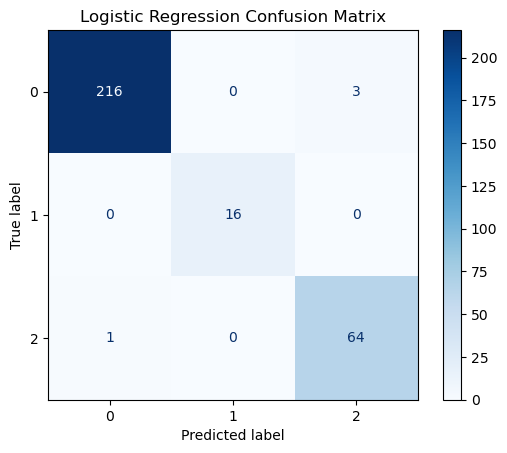


Accuracy: 0.9867


In [84]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

print("\n" + "="*50)
print("Logistic Regression")
print("="*50)

# Data Preparation ---------------------------------------------------
# Convert all features to numeric (safety check)
X_train_fixed = X_train.apply(pd.to_numeric, errors='coerce')
X_test_fixed = X_test.apply(pd.to_numeric, errors='coerce')

# Model Training -----------------------------------------------------
# Multinomial logistic regression with increased iterations
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_fixed, y_train)

# Model Evaluation ---------------------------------------------------
y_pred = lr.predict(X_test_fixed)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))  # Precision/recall/F1 scores

print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(lr, X_test_fixed, y_test, cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")  # Overall accuracy


K-Nearest Neighbors

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.96      0.83       219
           1       0.00      0.00      0.00        16
           2       0.31      0.06      0.10        65

    accuracy                           0.71       300
   macro avg       0.35      0.34      0.31       300
weighted avg       0.60      0.71      0.63       300


Confusion Matrix:


c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


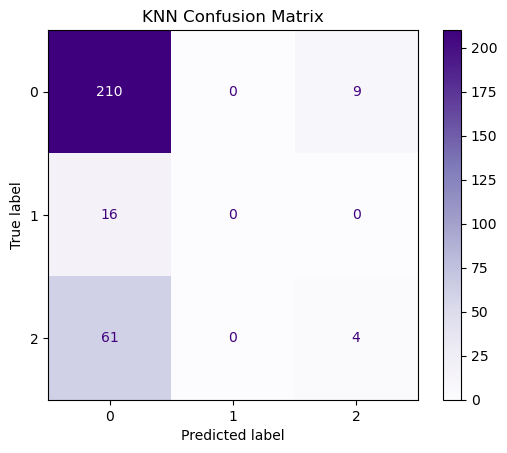


Accuracy: 0.7133


In [85]:
from sklearn.neighbors import KNeighborsClassifier

# Print section header
print("\n" + "="*50)
print("K-Nearest Neighbors")
print("="*50)

# Initialize KNN classifier with 5 neighbors
knn = KNeighborsClassifier(n_neighbors=5)  # Using 5 nearest points for classification
knn.fit(X_train, y_train)  # Train the model

# Make predictions on test data
y_pred = knn.predict(X_test)  

# Evaluate model performance
print("\nClassification Report:")  
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
disp = ConfusionMatrixDisplay.from_estimator(knn, X_test, y_test, cmap='Purples')
plt.title('KNN Confusion Matrix')  # Visual representation of predictions
plt.show()

# Print overall accuracy score
print(f"\nAccuracy: {accuracy_score(y_test, y_pred):.4f}")  

In [86]:
# Import required libraries
from sklearn.metrics import classification_report, accuracy_score
import pandas as pd
import matplotlib.pyplot as plt

# Print section header for clarity
print("\n" + "="*50)
print("MODEL PERFORMANCE COMPARISON")
print("="*50)

def get_model_metrics(model, X, y_true, model_name):
    """Calculate and return key performance metrics for a model"""
    y_pred = model.predict(X)  # Generate predictions
    report = classification_report(y_true, y_pred, output_dict=True)  # Get detailed metrics
    
    # Extract and return weighted average metrics
    return {
        'accuracy': accuracy_score(y_true, y_pred),  # Overall prediction accuracy
        'precision': report['weighted avg']['precision'],  # Positive predictive value
        'recall': report['weighted avg']['recall'],  # True positive rate
        'f1': report['weighted avg']['f1-score']  # Balance between precision and recall
    }

# Prepare test data for evaluation
X_test_numeric = X_test.apply(pd.to_numeric, errors='coerce').fillna(0)  # Ensure numeric values

# Dictionary of models to compare with their appropriate input data
models = {
    'Logistic Regression': (lr, X_test_numeric),  # Requires scaled data
    'KNN': (knn, X_test_numeric),

}

# Calculate metrics for each model
results = {}
for name, (model, data) in models.items():
    results[name] = get_model_metrics(model, data, y_test, name)

# Create and sort results dataframe by accuracy
results_df = pd.DataFrame.from_dict(results, orient='index')
results_df = results_df.sort_values('accuracy', ascending=False)

# Display numerical results
print("\nModel Performance Comparison:")
print(results_df)

# # Visualize results with enhanced y-axis focus
# plt.figure(figsize=(12,6))
# results_df[['accuracy', 'precision', 'recall', 'f1']].plot(kind='bar')
# plt.title('Model Performance Comparison (K=3 Clusters)')
# plt.ylabel('Performance Score (0.9-1.0)')
# plt.xticks(rotation=45)
# plt.ylim(0.9, 1.0)  # Focused range to highlight differences
# plt.tight_layout()
# plt.show()


MODEL PERFORMANCE COMPARISON


c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Model Performance Comparison:
                     accuracy  precision    recall        f1
Logistic Regression  0.986667   0.986934  0.986667  0.986737
KNN                  0.713333   0.600813  0.713333  0.628151


c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\adity\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
